In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
close_prices = pd.read_csv("../data/ten_stocks_wide.csv", index_col = "Date", parse_dates = True)

In [6]:
print("Shape: ", close_prices.shape)
close_prices.head()

Shape:  (1238, 10)


,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,KOTAKBANK.NS,MARUTI.NS,ONGC.NS,RELIANCE.NS,TCS.NS,WIPRO.NS
Date,,,,,,,,,,
2020-01-01,605.529358,1749.931396,519.138000,633.151123,333.417084,6945.335449,85.371376,672.216125,1841.149780,113.709183
2020-01-02,609.389160,1751.286865,522.861572,631.303650,332.919128,6962.575195,85.773300,683.660217,1832.698120,113.984612
2020-01-03,600.698792,1741.708374,521.169006,641.013367,330.041168,6890.763672,86.041237,684.484009,1869.221680,115.270004
2020-01-06,587.698853,1730.864502,508.450531,634.869690,329.134949,6689.528809,84.567574,668.609314,1869.052368,115.751991
2020-01-07,597.004761,1735.608643,505.742432,625.460693,332.779724,6719.166016,84.232666,678.895691,1873.638794,117.152122


In [34]:
daily_returns = (close_prices.pct_change() * 100).dropna()
daily_returns.head().style.format("{:.2f}%")

,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,KOTAKBANK.NS,MARUTI.NS,ONGC.NS,RELIANCE.NS,TCS.NS,WIPRO.NS
Date,,,,,,,,,,
2020-01-02 00:00:00,0.64%,0.08%,0.72%,-0.29%,-0.15%,0.25%,0.47%,1.70%,-0.46%,0.24%
2020-01-03 00:00:00,-1.43%,-0.55%,-0.32%,1.54%,-0.86%,-1.03%,0.31%,0.12%,1.99%,1.13%
2020-01-06 00:00:00,-2.16%,-0.62%,-2.44%,-0.96%,-0.27%,-2.92%,-1.71%,-2.32%,-0.01%,0.42%
2020-01-07 00:00:00,1.58%,0.27%,-0.53%,-1.48%,1.11%,0.44%,-0.40%,1.54%,0.25%,1.21%
2020-01-08 00:00:00,-0.26%,0.45%,0.58%,-1.33%,-0.96%,-0.54%,-1.83%,-0.75%,2.24%,-0.16%


In [44]:
#best and worst days 
for stock, ret in daily_returns.items():
    print(f"{stock}:")
    print(f"    Best Day: {ret.idxmax().strftime("%Y-%m-%d")} -> {ret.max().round(2)}%")
    print(f"    Worst Day: {ret.idxmin().strftime("%Y-%m-%d")} -> {ret.min().round(2)}%")


HDFCBANK.NS:
    Best Day: 2020-03-25 -> 11.6%
    Worst Day: 2020-03-23 -> -12.61%
HINDUNILVR.NS:
    Best Day: 2020-04-07 -> 13.5%
    Worst Day: 2020-03-23 -> -8.87%
ICICIBANK.NS:
    Best Day: 2020-04-07 -> 13.76%
    Worst Day: 2020-03-23 -> -17.85%
INFY.NS:
    Best Day: 2020-03-24 -> 12.03%
    Worst Day: 2020-03-23 -> -10.04%
KOTAKBANK.NS:
    Best Day: 2020-10-27 -> 12.05%
    Worst Day: 2020-03-23 -> -13.0%
MARUTI.NS:
    Best Day: 2020-04-07 -> 13.51%
    Worst Day: 2020-03-23 -> -16.91%
ONGC.NS:
    Best Day: 2020-03-20 -> 18.51%
    Worst Day: 2024-06-04 -> -16.83%
RELIANCE.NS:
    Best Day: 2020-03-25 -> 14.72%
    Worst Day: 2020-03-23 -> -13.15%
TCS.NS:
    Best Day: 2020-03-20 -> 9.85%
    Worst Day: 2020-03-12 -> -9.41%
WIPRO.NS:
    Best Day: 2020-07-15 -> 16.78%
    Worst Day: 2024-07-22 -> -9.22%


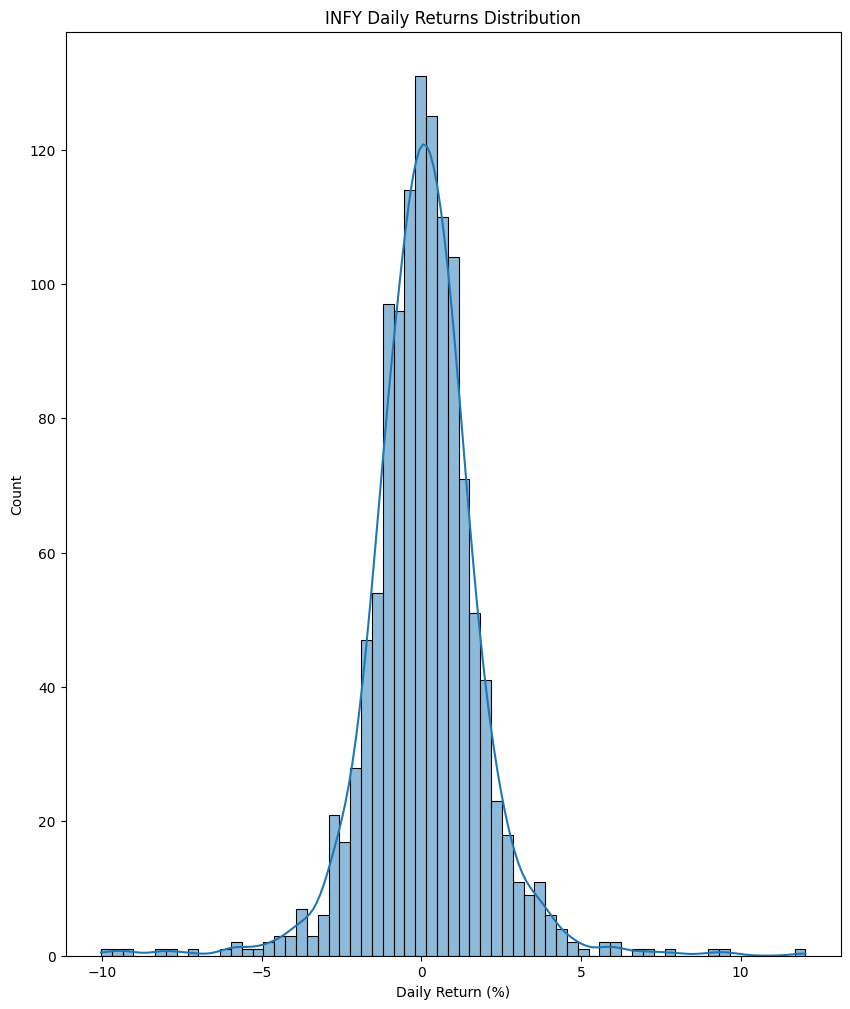

In [46]:
plt.figure(figsize = (10,12))
sns.histplot(data = daily_returns["INFY.NS"], kde = True)
plt.title("INFY Daily Returns Distribution")
plt.xlabel("Daily Return (%)")
plt.show()

In [53]:
average_daily_returns = daily_returns.mean()
print(average_daily_returns.round(2))

HDFCBANK.NS      0.04
HINDUNILVR.NS    0.03
ICICIBANK.NS     0.09
INFY.NS          0.10
KOTAKBANK.NS     0.02
MARUTI.NS        0.05
ONGC.NS          0.11
RELIANCE.NS      0.06
TCS.NS           0.07
WIPRO.NS         0.09
dtype: float64


In [56]:
daily_returns.to_csv("../data/daily_returns.csv")